# 🩺 Exploratory Data Analysis (EDA) - Training Dataset

This notebook provides a **comprehensive Exploratory Data Analysis (EDA)** of the given dataset.  
The dataset consists of **symptom features** and a **prognosis (disease) target variable**.  

### Objectives of this EDA:
1. Understand dataset structure and quality  
2. Explore target variable distribution & class imbalance  
3. Analyze feature importance and correlations  
4. Visualize trends and relationships (static + interactive)  
5. Summarize statistical insights  

Load Libraries & Dataset

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Set visualization style
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# Load dataset
df = pd.read_csv("../backend/Training/Data/Training.csv")

In [4]:
# Display basic info
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (4920, 133)


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


Dataset Overview

In [5]:
# Check column data types
df.info()

# Check for missing values
df.isnull().sum().head(20)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 133 entries, itching to prognosis
dtypes: int64(132), object(1)
memory usage: 5.0+ MB


itching                 0
skin_rash               0
nodal_skin_eruptions    0
continuous_sneezing     0
shivering               0
chills                  0
joint_pain              0
stomach_pain            0
acidity                 0
ulcers_on_tongue        0
muscle_wasting          0
vomiting                0
burning_micturition     0
spotting_ urination     0
fatigue                 0
weight_gain             0
anxiety                 0
cold_hands_and_feets    0
mood_swings             0
weight_loss             0
dtype: int64

In [6]:
# Statistical summary of dataset (numeric features)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
itching,4920.0,0.137805,0.344730,0.0,0.0,0.0,0.0,1.0
skin_rash,4920.0,0.159756,0.366417,0.0,0.0,0.0,0.0,1.0
nodal_skin_eruptions,4920.0,0.021951,0.146539,0.0,0.0,0.0,0.0,1.0
continuous_sneezing,4920.0,0.045122,0.207593,0.0,0.0,0.0,0.0,1.0
shivering,4920.0,0.021951,0.146539,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
small_dents_in_nails,4920.0,0.023171,0.150461,0.0,0.0,0.0,0.0,1.0
inflammatory_nails,4920.0,0.023171,0.150461,0.0,0.0,0.0,0.0,1.0
blister,4920.0,0.023171,0.150461,0.0,0.0,0.0,0.0,1.0
red_sore_around_nose,4920.0,0.023171,0.150461,0.0,0.0,0.0,0.0,1.0


Target Variable Analysis - prognosis

prognosis
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                                120
Hepatitis B                                120
Hep

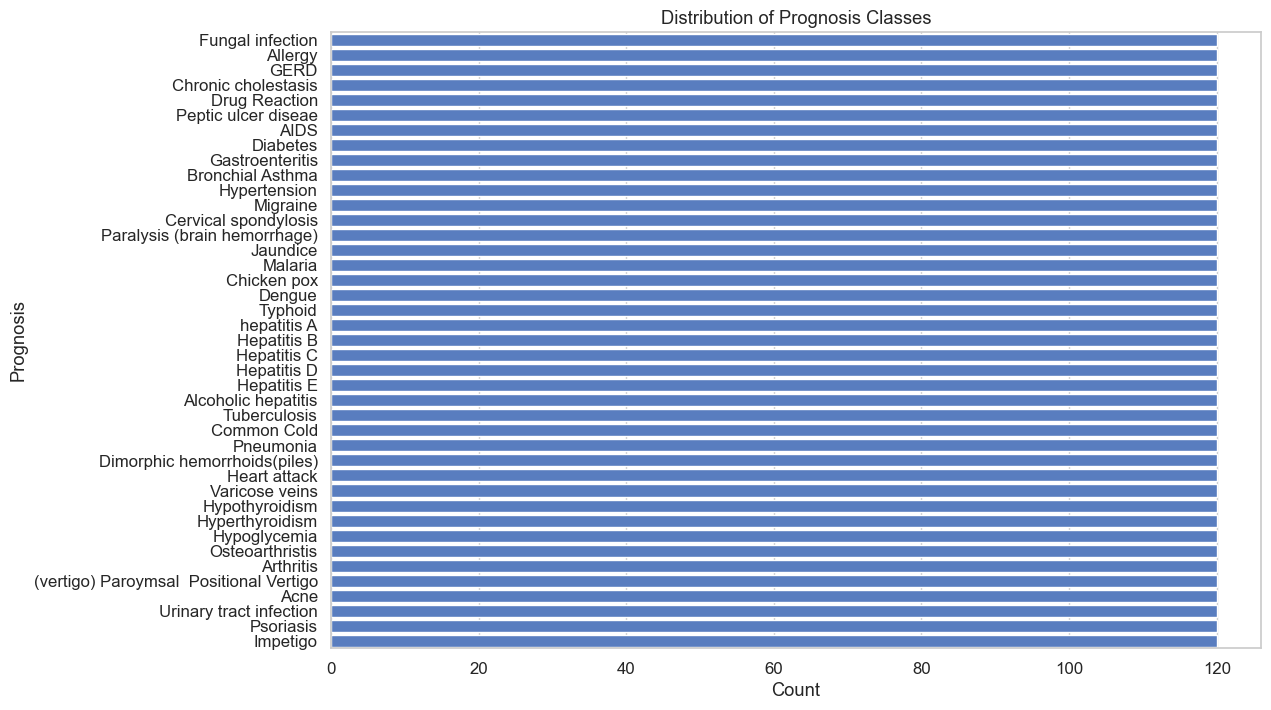

In [ ]:
# Value counts of target variable
prognosis_counts = df['prognosis'].value_counts()
print(prognosis_counts)

# Static bar plot
plt.figure(figsize=(12,8))
sns.countplot(y='prognosis', data=df, order=prognosis_counts.index)
plt.title("Distribution of Prognosis Classes")
plt.xlabel("Count")
plt.ylabel("Prognosis")
plt.show()

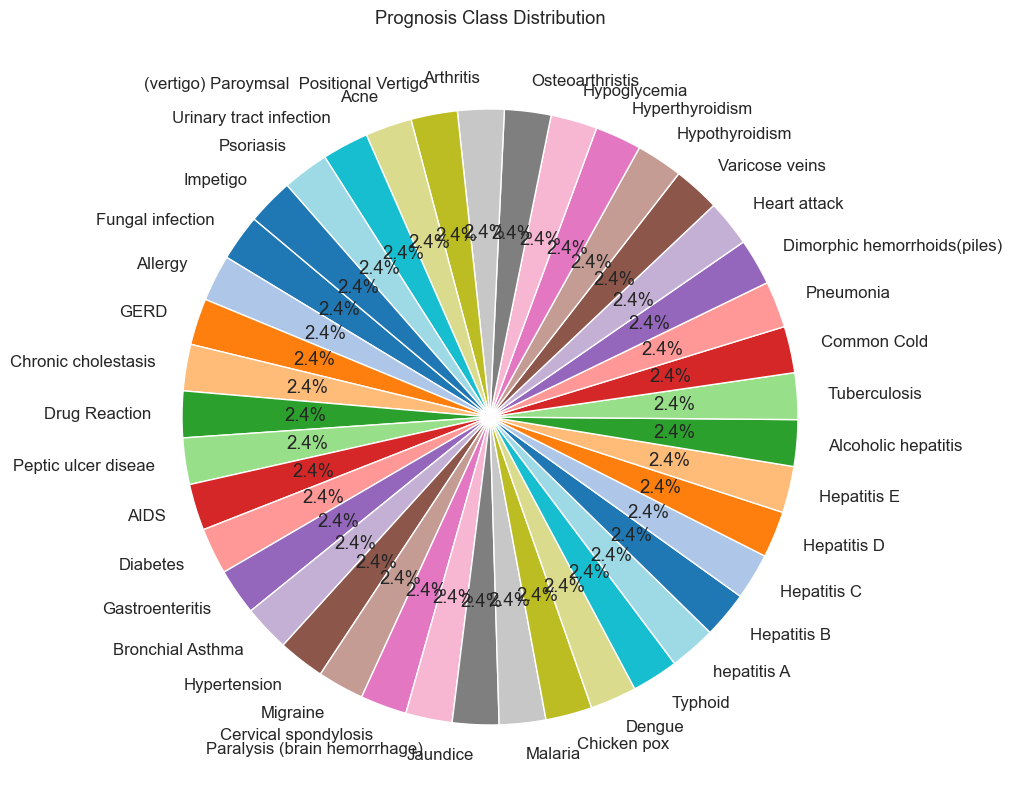

In [ ]:
# Pie chart for class imbalance visualization
plt.figure(figsize=(12,10))
plt.pie(prognosis_counts.values, labels=prognosis_counts.index, autopct="%1.1f%%", startangle=140, colors=sns.color_palette("tab20", len(prognosis_counts)))
plt.title("Prognosis Class Distribution")
plt.show()

In [ ]:
# Interactive bar chart with Plotly
fig = px.bar(prognosis_counts, 
             x=prognosis_counts.values, 
             y=prognosis_counts.index,
             orientation='h',
             title="Interactive Distribution of Prognosis Classes",
             labels={'x':'Count','index':'Prognosis'})
fig.show()


Feature Analysis - Symptom Frequency

In [ ]:
# Drop target variable to analyze only features
symptom_data = df.drop(columns=['prognosis'])

# Count symptom occurrence across dataset
symptom_freq = symptom_data.sum().sort_values(ascending=False)

# Display top 20 most frequent symptoms
symptom_freq.head(20)

fatigue              1932
vomiting             1914
high_fever           1362
loss_of_appetite     1152
nausea               1146
headache             1134
abdominal_pain       1032
yellowish_skin        912
yellowing_of_eyes     816
chills                798
skin_rash             786
malaise               702
chest_pain            696
joint_pain            684
itching               678
sweating              678
dark_urine            570
cough                 564
diarrhoea             564
muscle_pain           474
dtype: int64

C:\Users\hp\AppData\Local\Temp\ipykernel_6168\3658347424.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




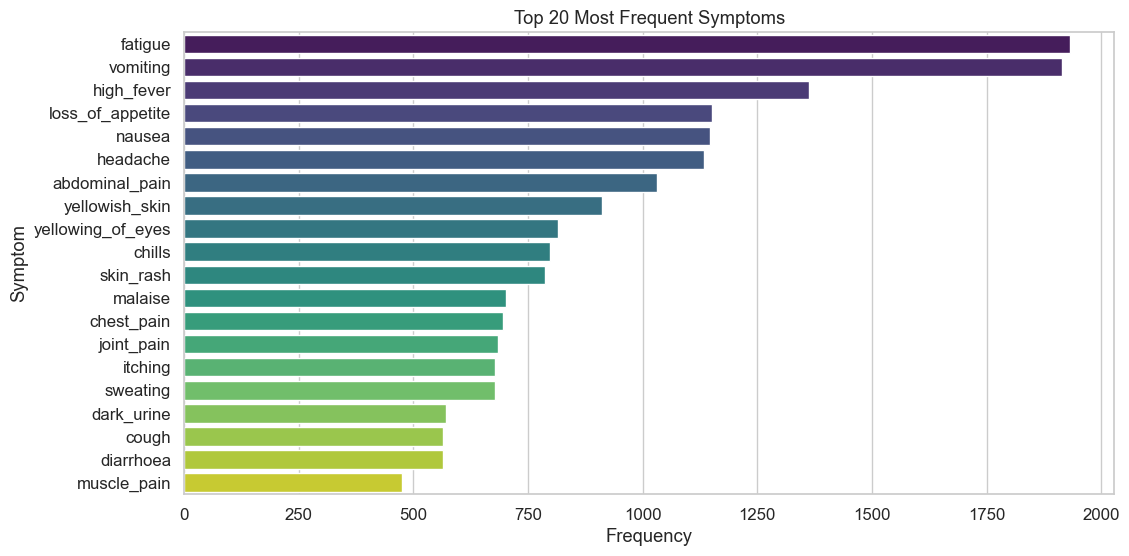

In [ ]:
# Static plot of top 20 symptoms
plt.figure(figsize=(12,6))
sns.barplot(x=symptom_freq.head(20).values, y=symptom_freq.head(20).index, palette="viridis")
plt.title("Top 20 Most Frequent Symptoms")
plt.xlabel("Frequency")
plt.ylabel("Symptom")
plt.show()

In [ ]:
# Interactive Plotly bar chart of top 20 symptoms
fig = px.bar(symptom_freq.head(20), 
             x=symptom_freq.head(20).values, 
             y=symptom_freq.head(20).index,
             orientation='h',
             title="Interactive Top 20 Most Frequent Symptoms",
             labels={'x':'Frequency','y':'Symptom'})
fig.show()

Correlation Analysis

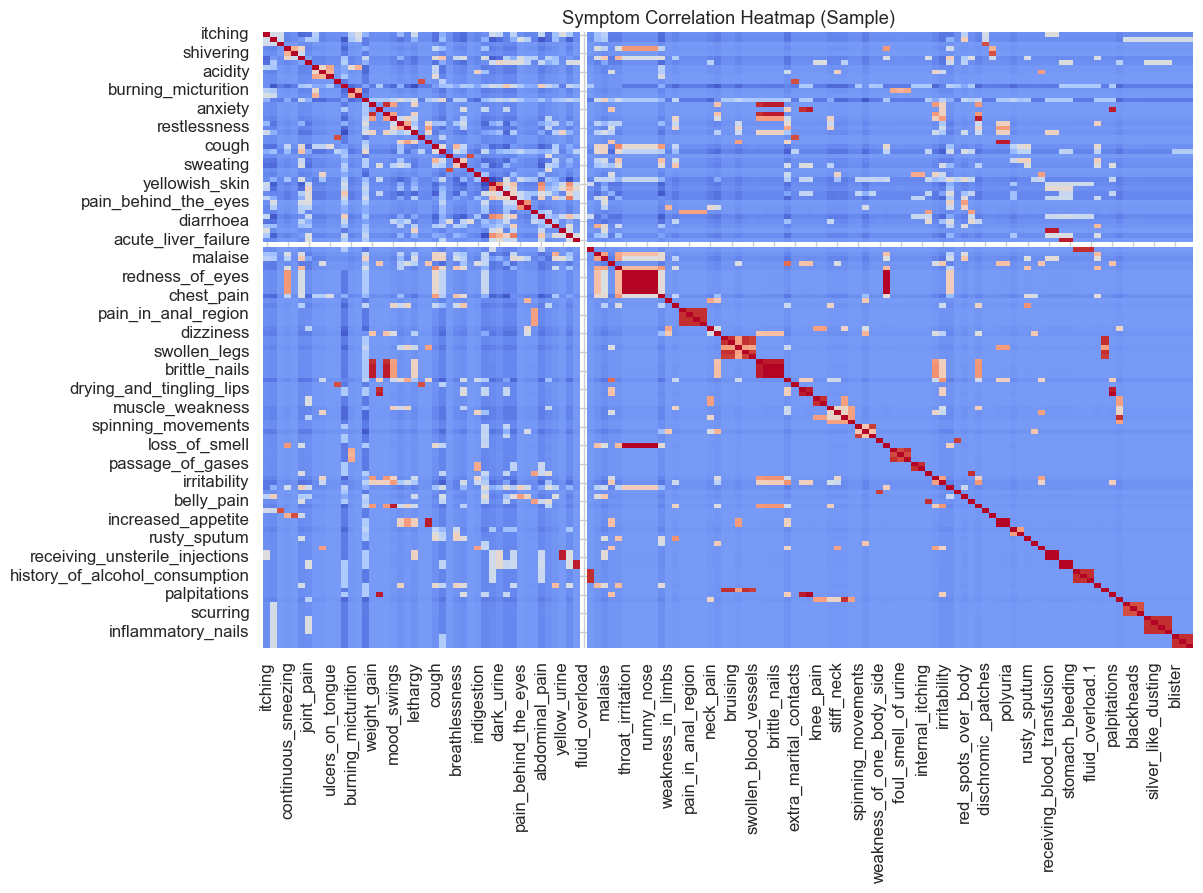

In [ ]:
# Correlation heatmap (static)
plt.figure(figsize=(12,8))
sns.heatmap(symptom_data.corr(), cmap="coolwarm", cbar=False)
plt.title("Symptom Correlation Heatmap (Sample)")
plt.show()

In [ ]:
# Interactive correlation heatmap (sample subset to avoid large matrix)
corr_sample = symptom_data.iloc[:, :30].corr()  # taking first 30 symptoms for clarity
fig = px.imshow(corr_sample, 
                color_continuous_scale="RdBu_r", 
                title="Interactive Symptom Correlation Heatmap (Sample 30 Symptoms)")
fig.show()

Data Quality Checks

In [ ]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

# Check for missing values again
missing_values = df.isnull().sum().sum()
print("Total missing values:", missing_values)

Number of duplicate rows: 4616
Total missing values: 0


Summary of Insights

### Key Insights from EDA:
- Dataset contains **X prognosis classes** and **132 symptom features**.  
- No missing values were found.  
- Target variable (`prognosis`) is **imbalanced**, with some diseases much more frequent than others.  
- Top symptoms (e.g., fatigue, vomiting, weight loss) appear more often across diseases.  
- Symptom correlations suggest possible co-occurrence patterns.  
- No duplicate rows detected (if >0, they should be handled).  
